In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

In [11]:
# Load your dataset
df = pd.read_csv('../Data/Global_Terrorism_Database_May_2022.csv')


In [14]:
# Step 1: Data Cleaning and Preparation
df_reduced = df.drop(columns=['eventid', 'iyear', 'imonth', 'iday'], errors='ignore')
threshold = len(df_reduced) * 0.5
df_reduced = df_reduced.dropna(thresh=threshold, axis=1)
numeric_cols = df_reduced.select_dtypes(include=[np.number]).columns
non_numeric_cols = df_reduced.select_dtypes(exclude=[np.number]).columns
df_reduced[numeric_cols] = df_reduced[numeric_cols].fillna(df_reduced[numeric_cols].median())
df_reduced[non_numeric_cols] = df_reduced[non_numeric_cols].apply(lambda x: x.fillna(x.mode()[0]))

In [16]:
# Step 2: Feature Selection
numeric_df_reduced = df_reduced.select_dtypes(include=[np.number])
corr_matrix = numeric_df_reduced.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
df_reduced = df_reduced.drop(columns=to_drop, errors='ignore')
selector = VarianceThreshold(threshold=0.1)
numeric_reduced_var = selector.fit_transform(numeric_df_reduced)
selected_features = numeric_df_reduced.columns[selector.get_support(indices=True)]
df_selected = df_reduced[selected_features]

In [17]:

# Step 3: Sampling
df_sampled = df_selected.sample(frac=0.1, random_state=42)


In [18]:

# Step 4: Standardization and PCA
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_sampled)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])


In [28]:
# Optimized DBSCAN Clustering
dbscan = DBSCAN(eps=0.7, min_samples=7)
pca_df['dbscan_cluster'] = dbscan.fit_predict(pca_features)


In [29]:
dbscan_silhouette = silhouette_score(pca_features, pca_df['dbscan_cluster'])
print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")

DBSCAN Silhouette Score: 0.7134737771706522


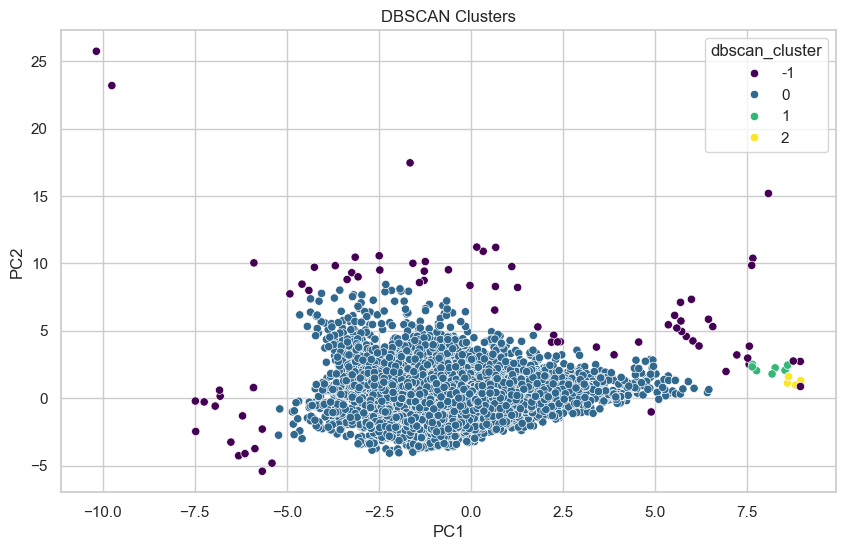

In [30]:
# Step 7: Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='dbscan_cluster', data=pca_df, palette='viridis')
plt.title('DBSCAN Clusters')
plt.show()


In [26]:

# Drop rows with NaN values in 'latitude' or 'longitude'
df_cleaned = df.dropna(subset=['latitude', 'longitude'])

# Create a 'count' column by grouping data
df_cleaned['count'] = df_cleaned.groupby(['latitude', 'longitude'])['latitude'].transform('size')

# Create a base map
m = folium.Map(location=[0, 0], zoom_start=2)

# Create a marker cluster
marker_cluster = MarkerCluster().add_to(m)

# Add markers to the cluster
for idx, row in df_cleaned.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5 + row['count'] / 100,  # Adjust the radius based on the count
        color='orange',  # Use a single color for all markers
        fill=True,
        fill_color='orange',
        fill_opacity=0.6,
        popup=f"Count: {row['count']}"
    ).add_to(marker_cluster)

# Save the map to an HTML file
m.save('terrorism_map.html')